# Import

In [1]:
import pandas as pd
import emoji
from wordcloud import WordCloud
import nltk
import matplotlib.pyplot as plt
from collections import Counter

import re
# nltk.download('stopwords')
from nltk.corpus import stopwords

In [2]:
df = pd.read_parquet('train.parquet')
df.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


In [3]:
df.shape

(8175, 2)

In [4]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [13]:
df['label'].value_counts()

label
spam        4125
not_spam    4050
Name: count, dtype: int64

# EDA

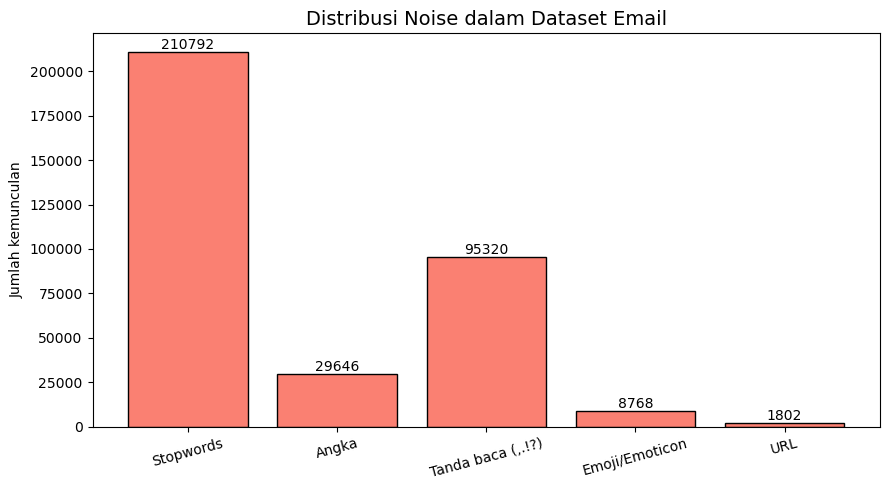

In [11]:
spam_text = ' '.join(df['text'].tolist())
stopword_en = set(stopwords.words('english'))

noise = {
    'Stopwords': sum(spam_text.lower().split().count(w) for w in stopword_en),
    'Angka': len(re.findall(r'\d', spam_text)),
    'Tanda baca (,.!?)': len(re.findall(r'[,\.!?;:\"\']', spam_text)),
    'Emoji/Emoticon': len(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', spam_text)),
    'URL': len(re.findall(r'http\S+|www\S+', spam_text)),
}

plt.figure(figsize=(9, 5))
bars = plt.bar(noise.keys(), noise.values(), color='salmon', edgecolor='black')
plt.bar_label(bars)
plt.title('Distribusi Noise dalam Dataset Email', fontsize=14)
plt.ylabel('Jumlah kemunculan')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [37]:
print(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', spam_text))

['👋', '👋', '👋', '😴', '😒', '🌶', '🌶', '🌶', '💪', '🏃', '🥦', '💪', '💪', '💪', '🙌', '🙌', '🙌', '🤩', '🤩', '🤩', '👋', '💥', '🤳', '🤳', '💻', '🔥', '🚫', '🔥', '🔥', '🤑', '💰', '💰', ':)', '👀', '📣', '📈', '🚀', '🤑', '👉', '💕', '💬', '🔧', '🛠', '👍', '📝', '👥', '🤩', '🌸', '🌸', '🌸', '🤩', '🤩', '🤩', '😝', '😝', '😝', '🤯', '🤯', '🤯', ';D', '😩', ':)', ':-|', ':-|', ':-|', '🎉', '🎉', '🎉', ';)', '🚨', '🚨', '🦐', '🦐', '🍔', '🍔', '🍟', '🍟', '💥', '💥', '🎁', '🤯', '🔥', '💥', '👨', '🎤', '👩', '🎤', '🔞', '🦄', '🤑', '🤑', '🤑', '🏃', '🏃', '🏃', '🥑', '🎉', '🥳', '💥', '🤑', '💪', '👟', '🌴', '🌞', '👀', '💬', '🤑', '💰', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '👉', '🏼', '🤯', '🤯', '🚫', '👉', '🤑', '🎉', '👍', '🙌', '🚨', '🚨', '🚨', '🚨', '🚨', '🚨', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🎉', '🎉', '🎉', '🎉', '🎉', '🎉', '🤑', '🤑', '🤑', '🤑', '🤑', '🚨', '🚨', '🏋', '🏋', '💪', '💪', '📚', '🤑', '💰', '🤑', '💰', '🤑', '📣', '📣', '📣', '😎', '🚨', '🚨', '🎉', '🎉', '🎉', '🤡', '🐱', '😜', '😂', '👌', '🔥', '🔥', '🔥', '🤑', '🤑', '🤑', '🎉', '🎉', '🎉', '🥧', '🥧', '🥧', '💰', '💰', '💰', '=p', '=p', '=p', '👉', '👉', '👉', '🤑', '

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_4312\1099320839.py:60: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


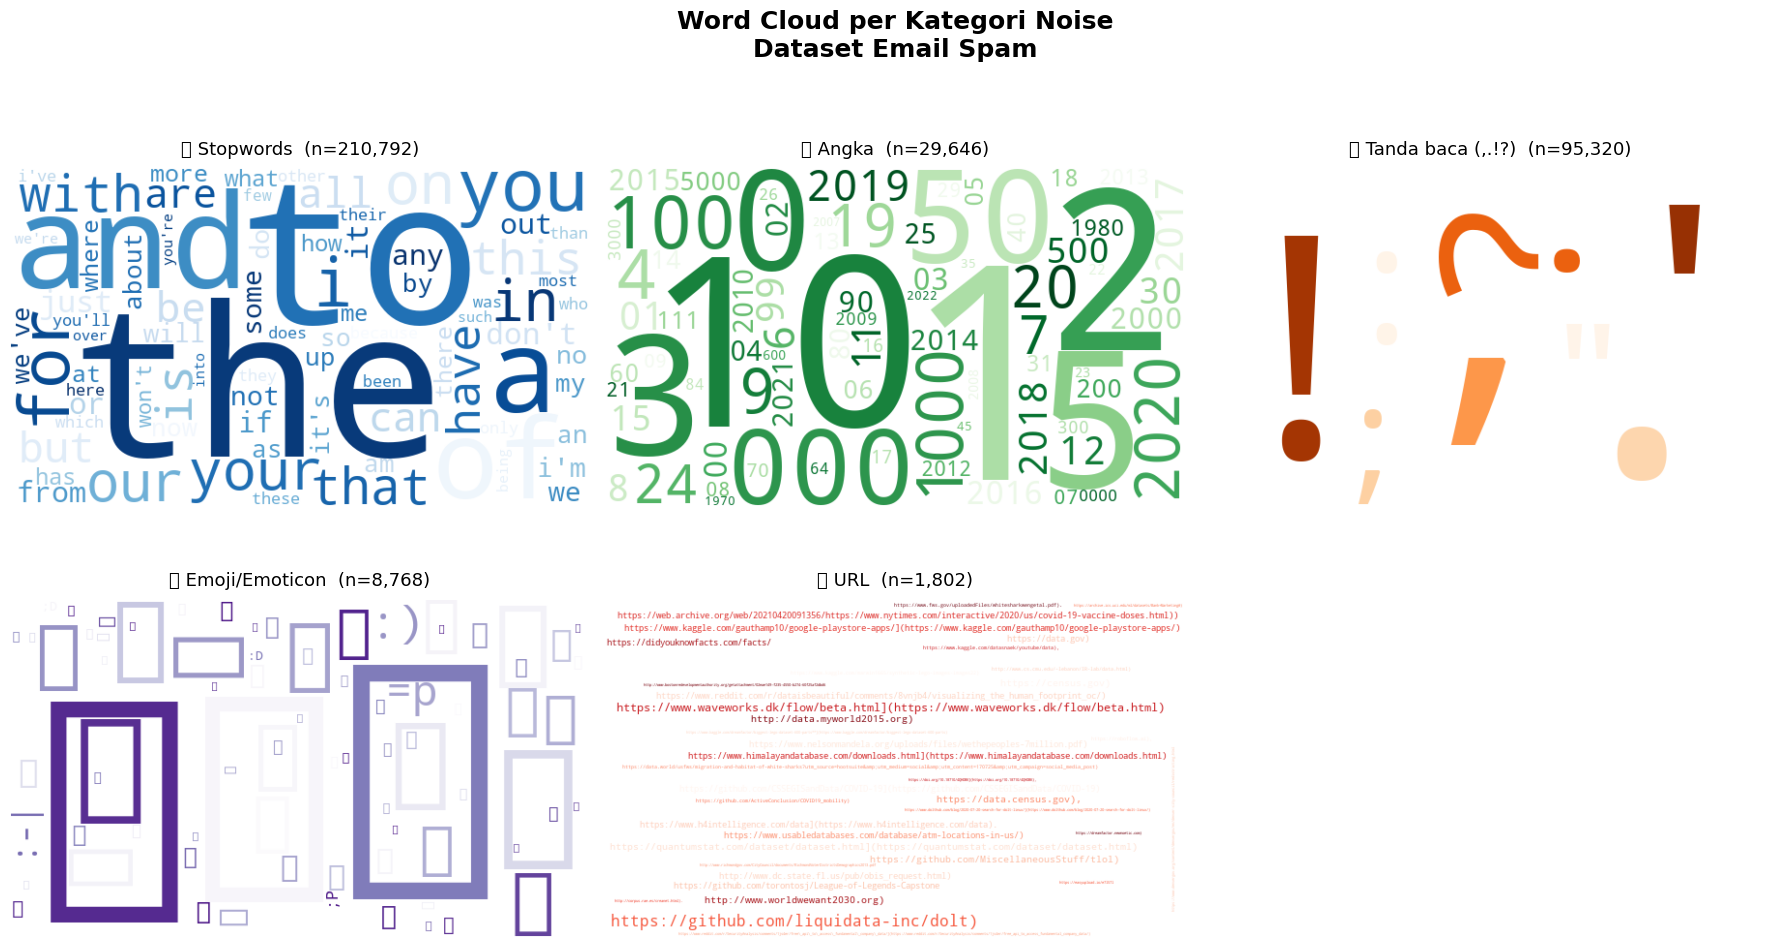

In [17]:
# ── Bangun freq dict untuk tiap key di noise ──────────────────────────────────
tokens = spam_text.lower().split()

noise_freq = {
    'Stopwords':            Counter(w for w in tokens if w in stopword_en),
    'Angka':                Counter(re.findall(r'\b\d+\b', spam_text)),
    'Tanda baca (,.!?)':    Counter(re.findall(r'[,\.!?;:\"\']', spam_text)),
    'Emoji/Emoticon':       Counter(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', spam_text)),
    'URL':                  Counter(re.findall(r'http\S+|www\S+', spam_text)),
}

# ── Colormap per kategori ─────────────────────────────────────────────────────
cmap_map = {
    'Stopwords':            'Blues',
    'Angka':                'Greens',
    'Tanda baca (,.!?)':    'Oranges',
    'Emoji/Emoticon':       'Purples',
    'URL':                  'Reds',
}

# ── make_wc helper ────────────────────────────────────────────────────────────
def make_wc(freq_dict, colormap, max_words=80):
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=max_words,
        collocations=False,
    )
    if freq_dict:
        wc.generate_from_frequencies(freq_dict)
    return wc

# ── Plot — otomatis ikut jumlah key di noise ──────────────────────────────────
n     = len(noise)
ncols = 3
nrows = -(-n // ncols)   # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
fig.suptitle('Word Cloud per Kategori Noise\nDataset Email Spam',
             fontsize=18, fontweight='bold', y=1.01)

for ax, (label, freq) in zip(axes.flatten(), noise_freq.items()):
    cmap = cmap_map.get(label, 'cool')
    if freq:
        wc = make_wc(freq, cmap)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'🔹 {label}  (n={noise[label]:,})', fontsize=13, pad=10)
    else:
        ax.text(0.5, 0.5, 'Tidak ditemukan',
                ha='center', va='center', fontsize=13, color='gray',
                transform=ax.transAxes)
        ax.set_title(f'🔹 {label}', fontsize=13, pad=10)
    ax.axis('off')

# Sembunyikan ax kosong jika noise ganjil
for ax in axes.flatten()[n:]:
    ax.set_visible(False)

plt.tight_layout()
# plt.savefig('wordcloud_noise.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
print(df['text'].apply(len).mean())
print(df['text'].apply(len).max())
print(df['text'].apply(len).min())

369.11131498470945
41544
2


In [5]:
df['text_length'] = df['text'].apply(len)

In [41]:
df[df['text_lenght'] == 41544]

,text,label,text_lenght
6262,I've made a zip code-level data retriever in R...,not_spam,41544


In [53]:
df[df['text_lenght'] == 0]

,text,label,text_lenght,text_casefolded


# Casefolding and Normalization

In [56]:
df.drop(['text_casefolded'], axis=1, inplace=True)

In [6]:
# lowercase
df['text_normalized'] = df['text'].str.lower()

# Remove \n
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub('\\n',' ', x).strip())

# Remove url
# df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(
#                                                     r'https?://\S+'      # https://... atau http://...
#                                                     r'|www\.\S+'         # www....
#                                                     r'|\S+\.\S+\.\S+'    # subdomain.domain.tld (links.aaruush.org)
#                                                     r'|\S+\.(com|org|net|id|io|co|info|edu|gov)\S*',  # domain.tld umum
#                                                     '', x))

# Remove Emoji
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]','', x).strip())

In [6]:
df[['text_normalized','text']]

,text_normalized,text
0,hey i am looking for xray baggage datasets can...,hey I am looking for Xray baggage datasets can...
1,"""get rich quick! make millions in just days wi...","""Get rich quick! Make millions in just days wi..."
2,urgent message: you won't believe what we have...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...
3,[google ai blog: contributing data to deepfake...,[Google AI Blog: Contributing Data to Deepfake...
4,trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...
...,...,...
8170,"hi all, we create datasets by taking pictures...","Hi all,\n\nWe create datasets by taking pictur..."
8171,deals! deals! deals! hey peeps! you won't bel...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...
8172,hi i am working on a project and need penalty...,Hi\n\nI am working on a project and need penal...
8173,do you want to blow up your social media follo...,Do you want to BLOW UP your social media follo...


In [3]:
def mask_urls(text):
    # Bedakan URL suspicious vs normal
    suspicious_patterns = r'(bit\.ly|tinyurl|goo\.gl|t\.co|shorturl)'
    # URL shortener → token khusus
    text = re.sub(
        rf'https?://\S*{suspicious_patterns}\S*', 
        ' shorturltoken ', text, flags=re.IGNORECASE
    )
    
    # URL biasa
    text = re.sub(
        r'https?://\S+', 
        ' urltoken ', text
    )
    
    # Naked domain (tanpa http)
    text = re.sub(
        r'\b(?:www\.)\S+\.\S+', 
        ' urltoken ', text
    )
    
    return text

df['mask_text'] = df['text'].apply(mask_urls)

In [4]:
def mask_currency(text):
    # Format Rp / IDR
    text = re.sub(
        r'Rp\.?\s?[\d.,]+(?:\s?(?:ribu|juta|miliar|rb|jt|M))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Format USD / simbol $
    text = re.sub(
        r'\$\s?[\d.,]+(?:\s?(?:thousand|million|billion))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Angka besar standalone (>= 4 digit) — hati-hati jangan overmask
    text = re.sub(
        r'\b\d{4,}(?:[.,]\d+)*\b',
        ' numbertoken ', text
    )
    
    return text

df['mask_text'] = df['mask_text'].apply(mask_currency)

In [5]:
def normalize_elongation(text, max_repeat=2):
    """
    Normalisasi karakter yang diulang berlebihan.
    
    Contoh:
        fireeee   → fire
        gratiisss → gratiss  (max_repeat=2, biar tetap bisa bedain 'free' vs 'freee')
        wooow     → woow
        hahaha    → hahaha (tidak terpengaruh, beda pola)
    """
    # Ganti karakter yang muncul > max_repeat kali berturut-turut
    pattern = rf'(.)\1{{{max_repeat},}}'
    return re.sub(pattern, r'\1' * max_repeat, text)

df['mask_text'] = df['mask_text'].apply(normalize_elongation)


In [17]:
df[['mask_text','text']]

,mask_text,text
0,hey I am looking for Xray baggage datasets can...,hey I am looking for Xray baggage datasets can...
1,"""Get rich quick! Make millions in just days wi...","""Get rich quick! Make millions in just days wi..."
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...
3,[Google AI Blog: Contributing Data to Deepfake...,[Google AI Blog: Contributing Data to Deepfake...
4,Trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...
...,...,...
8170,"Hi all,\n\nWe create datasets by taking pictur...","Hi all,\n\nWe create datasets by taking pictur..."
8171,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...
8172,Hi\n\nI am working on a project and need penal...,Hi\n\nI am working on a project and need penal...
8173,Do you want to BLOW UP your social media follo...,Do you want to BLOW UP your social media follo...


In [26]:
nltk.download('words')

[nltk_data] Downloading package words to
[nltk_data]     D:\Users\bsi80273\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\words.zip.


True

In [6]:
from nltk.corpus import words as nltk_words

english_words = set(nltk_words.words())

def normalize_elongation_smart(text):
    def fix_word(word):
        # Kurangi dulu ke max_repeat=2
        reduced = re.sub(r'(.)\1{2,}', r'\1\1', word)
        
        # Coba kurangi sampai ketemu di dictionary
        for n in range(len(reduced), 0, -1):
            candidate = re.sub(r'(.)\1+', lambda m: m.group(1) * min(len(m.group()), n), reduced)
            if candidate.lower() in english_words:
                return candidate
        
        return reduced  # fallback ke max_repeat=2
    
    return ' '.join(fix_word(w) for w in text.split())


df['text_normalized'] = df['mask_text'].apply(normalize_elongation)


# lowercase


# Remove \n
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub('\\n',' ', x).strip())

# Remove url
# df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(
#                                                     r'https?://\S+'      # https://... atau http://...
#                                                     r'|www\.\S+'         # www....
#                                                     r'|\S+\.\S+\.\S+'    # subdomain.domain.tld (links.aaruush.org)
#                                                     r'|\S+\.(com|org|net|id|io|co|info|edu|gov)\S*',  # domain.tld umum
#                                                     '', x))

# Remove Emoji
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]','', x).strip())


def remove_punctuation(text):
    """
    Hapus punctuation tapi JAGA token masking (URLTOKEN, NOMINALTOKEN, dst)
    dan angka yang masih tersisa.
    
    Contoh:
        "Klik URLTOKEN sekarang!!!"     → "Klik URLTOKEN sekarang"
        "Gratis??? Hub. kami 08123..."  → "Gratis Hub kami 08123"
        "harga: Rp.10rb/hari"          → "harga Rp10rbbari"  ← (sudah di-mask sebelumnya)
    """
    # Hapus semua karakter selain huruf, angka, dan spasi
    text = re.sub(r'[^\w\s]', '', text)
    
    # Normalisasi spasi ganda hasil hapus punctuation
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['text_normalized'] = df['text_normalized'].apply(remove_punctuation)



#Csefild
df['text_normalized'] = df['text_normalized'].str.lower()

#Remove space on start/end character
df['text_normalized'] = df['text_normalized'].str.strip()

In [31]:
df

,text,label,text_length,text_normalized,mask_text
0,hey I am looking for Xray baggage datasets can...,not_spam,76,hey i am looking for xray baggage datasets can...,hey I am looking for Xray baggage datasets can...
1,"""Get rich quick! Make millions in just days wi...",spam,129,get rich quick make millions in just days with...,"""Get rich quick! Make millions in just days wi..."
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam,495,urgent message you wont believe what we have t...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam,1057,google ai blog contributing data to deepfake d...,[Google AI Blog: Contributing Data to Deepfake...
4,Trying to see if anyone already has timestamps...,not_spam,223,trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...
...,...,...,...,...,...
8170,"Hi all,\n\nWe create datasets by taking pictur...",not_spam,832,hi all we create datasets by taking pictures o...,"Hi all,\n\nWe create datasets by taking pictur..."
8171,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,spam,509,deals deals deals hey peeps you wont believe t...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...
8172,Hi\n\nI am working on a project and need penal...,not_spam,200,hi i am working on a project and need penalty ...,Hi\n\nI am working on a project and need penal...
8173,Do you want to BLOW UP your social media follo...,spam,355,do you want to blow up your social media follo...,Do you want to BLOW UP your social media follo...


# Lemma

In [32]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to
[nltk_data]     D:\Users\bsi80273\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     D:\Users\bsi80273\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

In [38]:
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     D:\Users\bsi80273\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [7]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk


lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tag ke format WordNet"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_map.get(tag, wordnet.NOUN)  # default NOUN

MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}

def apply_lemmatization(text):
    words = text.split()
    result = [
        word if word in MASK_TOKENS
        else lemmatizer.lemmatize(word, get_wordnet_pos(word))
        for word in words
    ]
    return ' '.join(result)

df['lemma'] = df['text_normalized'].apply(apply_lemmatization)

# Remove stoprword

In [8]:
from nltk.corpus import stopwords

MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}

# Kata yang TIDAK boleh dihapus meski ada di stopword list
SPAM_WHITELIST = {'no', 'not', 'free', 'won', 'win', 'never', 'now', 'only'}

BASE_STOPWORDS = set(stopwords.words('english'))
FINAL_STOPWORDS = BASE_STOPWORDS - SPAM_WHITELIST  # exclude whitelist

def remove_stopwords(text):
    words = text.split()
    result = [
        word for word in words
        if word in MASK_TOKENS or word not in FINAL_STOPWORDS
    ]
    return ' '.join(result)


df['text_remove_sw'] = df['lemma'].apply(remove_stopwords)

In [41]:
df

,text,label,text_length,text_normalized,mask_text,lemma,text_remove_sw
0,hey I am looking for Xray baggage datasets can...,not_spam,76,hey i am looking for xray baggage datasets can...,hey I am looking for Xray baggage datasets can...,hey i be look for xray baggage datasets can yo...,hey look xray baggage datasets provide
1,"""Get rich quick! Make millions in just days wi...",spam,129,get rich quick make millions in just days with...,"""Get rich quick! Make millions in just days wi...",get rich quick make million in just day with o...,get rich quick make million day new revolution...
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam,495,urgent message you wont believe what we have t...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,urgent message you wont believe what we have t...,urgent message wont believe offer hey yeah eye...
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam,1057,google ai blog contributing data to deepfake d...,[Google AI Blog: Contributing Data to Deepfake...,google ai blog contribute data to deepfake det...,google ai blog contribute data deepfake detect...
4,Trying to see if anyone already has timestamps...,not_spam,223,trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...,try to see if anyone already have timestamps o...,try see anyone already timestamps key event ha...
...,...,...,...,...,...,...,...
8170,"Hi all,\n\nWe create datasets by taking pictur...",not_spam,832,hi all we create datasets by taking pictures o...,"Hi all,\n\nWe create datasets by taking pictur...",hi all we create datasets by take picture of s...,hi create datasets take picture specific objec...
8171,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,spam,509,deals deals deals hey peeps you wont believe t...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,deal deal deal hey peep you wont believe the a...,deal deal deal hey peep wont believe amaze dea...
8172,Hi\n\nI am working on a project and need penal...,not_spam,200,hi i am working on a project and need penalty ...,Hi\n\nI am working on a project and need penal...,hi i be work on a project and need penalty con...,hi work project need penalty concede score odd...
8173,Do you want to BLOW UP your social media follo...,spam,355,do you want to blow up your social media follo...,Do you want to BLOW UP your social media follo...,do you want to blow up your social medium foll...,want blow social medium follower instantly loo...


In [9]:
df = df[df['text_remove_sw'] != '']


In [19]:
len(all_words)

141281

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_32452\3330229198.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


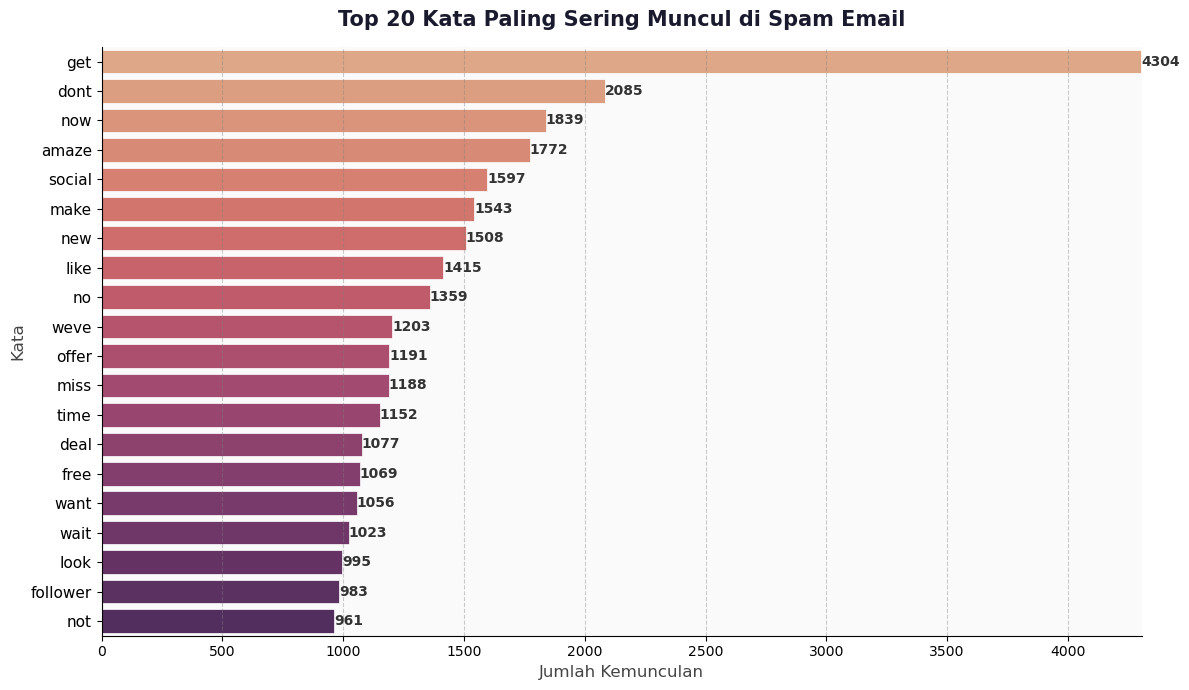

In [17]:
import seaborn as sns
all_words = ' '.join(df[df['label'] == 1]['text_remove_sw']).split()
 
# ── Top 20 kata ───────────────────────────────────────────────────────────────
counter = Counter(all_words)
top20 = pd.DataFrame(counter.most_common(20), columns=["word", "count"])
 
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
 
palette = sns.color_palette("flare", n_colors=20)
 
sns.barplot(
    data=top20,
    x="count",
    y="word",
    palette=palette,
    orient="h",
    ax=ax,
    edgecolor="white",
    linewidth=0.5,
)
 
# Anotasi nilai di ujung bar
for i, (val, word) in enumerate(zip(top20["count"], top20["word"])):
    ax.text(val + 0.2, i, str(val), va="center", fontsize=10, color="#333333", fontweight="bold")
 
# Styling
ax.set_title("Top 20 Kata Paling Sering Muncul di Spam Email",
             fontsize=15, fontweight="bold", pad=15, color="#1a1a2e")
ax.set_xlabel("Jumlah Kemunculan", fontsize=12, color="#444")
ax.set_ylabel("Kata", fontsize=12, color="#444")
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.set_xlim(0, top20["count"].max() + 3)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4, color="gray")
ax.set_facecolor("#fafafa")
fig.patch.set_facecolor("#ffffff")
 
plt.tight_layout()


D:\Users\bsi80273\AppData\Local\Temp\ipykernel_32452\1785322310.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


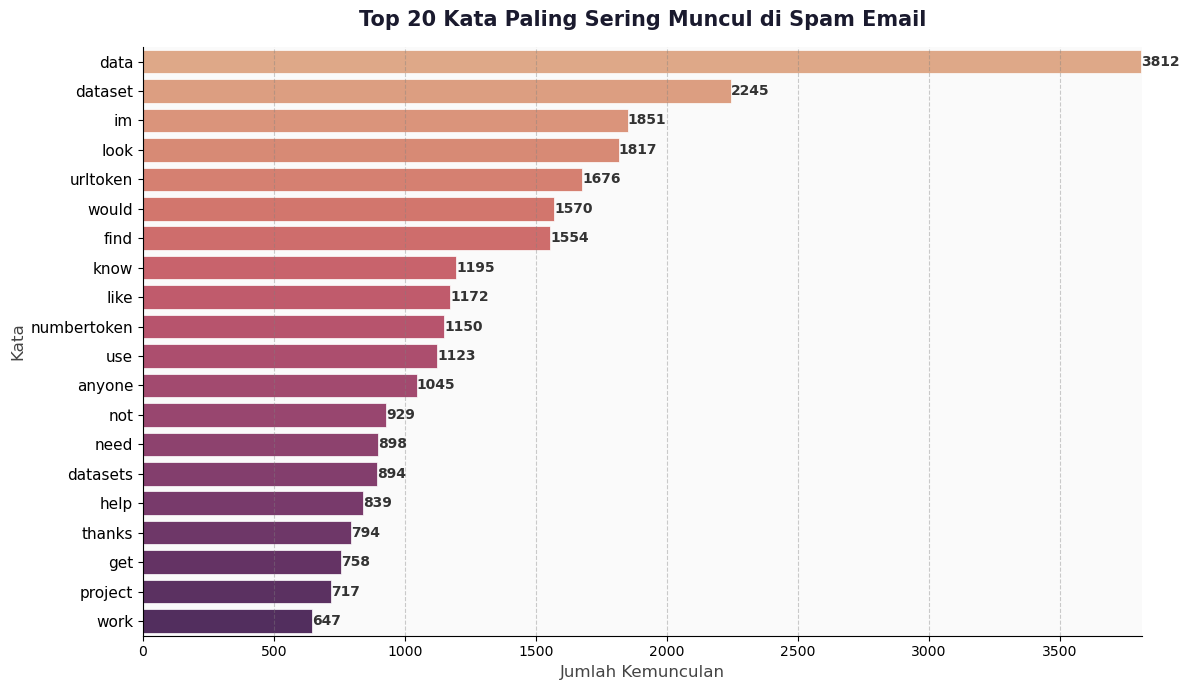

In [18]:
import seaborn as sns
all_words = ' '.join(df[df['label'] == 0]['text_remove_sw']).split()
 
# ── Top 20 kata ───────────────────────────────────────────────────────────────
counter = Counter(all_words)
top20 = pd.DataFrame(counter.most_common(20), columns=["word", "count"])
 
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
 
palette = sns.color_palette("flare", n_colors=20)
 
sns.barplot(
    data=top20,
    x="count",
    y="word",
    palette=palette,
    orient="h",
    ax=ax,
    edgecolor="white",
    linewidth=0.5,
)
 
# Anotasi nilai di ujung bar
for i, (val, word) in enumerate(zip(top20["count"], top20["word"])):
    ax.text(val + 0.2, i, str(val), va="center", fontsize=10, color="#333333", fontweight="bold")
 
# Styling
ax.set_title("Top 20 Kata Paling Sering Muncul di Spam Email",
             fontsize=15, fontweight="bold", pad=15, color="#1a1a2e")
ax.set_xlabel("Jumlah Kemunculan", fontsize=12, color="#444")
ax.set_ylabel("Kata", fontsize=12, color="#444")
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.set_xlim(0, top20["count"].max() + 3)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4, color="gray")
ax.set_facecolor("#fafafa")
fig.patch.set_facecolor("#ffffff")
 
plt.tight_layout()


# Encoding

In [10]:
df['label'] = df['label'].map({"spam" : 1, "not_spam" : 0})
df.head()

,text,label,mask_text,text_normalized,lemma,text_remove_sw
0,hey I am looking for Xray baggage datasets can...,0,hey I am looking for Xray baggage datasets can...,hey i am looking for xray baggage datasets can...,hey i be look for xray baggage datasets can yo...,hey look xray baggage datasets provide
1,"""Get rich quick! Make millions in just days wi...",1,"""Get rich quick! Make millions in just days wi...",get rich quick make millions in just days with...,get rich quick make million in just day with o...,get rich quick make million day new revolution...
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,urgent message you wont believe what we have t...,urgent message you wont believe what we have t...,urgent message wont believe offer hey yeah eye...
3,[Google AI Blog: Contributing Data to Deepfake...,0,[Google AI Blog: Contributing Data to Deepfake...,google ai blog contributing data to deepfake d...,google ai blog contribute data to deepfake det...,google ai blog contribute data deepfake detect...
4,Trying to see if anyone already has timestamps...,0,Trying to see if anyone already has timestamps...,trying to see if anyone already has timestamps...,try to see if anyone already have timestamps o...,try see anyone already timestamps key event ha...


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
 
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
# Ganti dengan path dataset kamu
# df = pd.read_csv("dataset_preprocessed.csv")
 
# Pastikan kolom 'text' dan 'label' ada
# label: 1 = spam, 0 = ham
X = df["text"]
y = df["label"]
 
print(f"Total data  : {len(df)}")
print(f"Distribusi  :\n{y.value_counts()}")
 
# ─────────────────────────────────────────────
# 2. TRAIN-TEST SPLIT
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
# ─────────────────────────────────────────────
# 3. TF-IDF VECTORIZER
# ─────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=30763,       # ambil 5000 kata paling informatif
    ngram_range=(1, 2),      # unigram + bigram
    sublinear_tf=True,       # log normalization pada TF
)
 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
 
print(f"\nShape matrix TF-IDF train : {X_train_tfidf.shape}")
print(f"Shape matrix TF-IDF test  : {X_test_tfidf.shape}")


Total data  : 8174
Distribusi  :
label
1    4125
0    4049
Name: count, dtype: int64

Shape matrix TF-IDF train : (6539, 30763)
Shape matrix TF-IDF test  : (1635, 30763)


In [38]:
import math
tfidf_full = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
)
tfidf_full.fit(X_train)  # ganti 'corpus' dengan data teks kamu

total_vocab = len(tfidf_full.vocabulary_)
print(f"Total vocab: {total_vocab}")

# Step 2: Hitung 20% (Pareto)
pareto_features = math.ceil(total_vocab * 0.20)
print(f"Pareto 20% → max_features: {pareto_features}")

Total vocab: 153814
Pareto 20% → max_features: 30763


# Logistic Reg

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np


selector = SelectKBest(chi2, k=30763)
X_selected = selector.fit_transform(X_train_tfidf, y_train)

# Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='precision')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

Akurasi tiap fold : [1. 1. 1.]
Rata-rata          : 1.0000
Std deviasi        : 0.0000


In [54]:
X_test_selected = selector.transform(X_test_tfidf)

model.fit(X_train_tfidf, y_train)

# Transform X_test
X_test_tfidf    = tfidf.transform(X_test)
X_test_selected = selector.transform(X_test_tfidf)

# Evaluasi di test set
y_pred = model.predict(X_test_selected)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# KNN

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

knn = KNeighborsClassifier()

# Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(knn, X_selected, y_train, cv=cv, scoring='precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

# Train + evaluasi di test set
knn.fit(X_selected, y_train)
y_pred_knn = knn.predict(X_test_selected)

from sklearn.metrics import classification_report
print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_knn))



Akurasi tiap fold : [0.99724933 0.98573605 0.99679784]
Rata-rata          : 0.9933
Std deviasi        : 0.0053

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       810
           1       0.98      1.00      0.99       825

    accuracy                           0.99      1635
   macro avg       0.99      0.99      0.99      1635
weighted avg       0.99      0.99      0.99      1635



In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import make_scorer, precision_score

scorer = make_scorer(precision_score, pos_label=1)  # atau pos_label='spam'

# ── Grid Search ──────────────────────────────────────────────────────────────
param_grid = {
    'n_neighbors': [3, 4, 5, 6],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['minkowski','euclidean', 'manhattan', 'cosine'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = KNeighborsClassifier(),
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'precision_weighted',   # ganti sesuai kebutuhan
    n_jobs     = -1,                     # pakai semua core
    verbose    = 1,
    refit      = True                    # otomatis refit pakai best params
)

grid_search.fit(X_selected, y_train)

# ── Hasil Grid Search ────────────────────────────────────────────────────────
print("Best params  :", grid_search.best_params_)
print(f"Best CV score: {grid_search.best_score_:.4f}")

# ── Cross Validation ulang pakai best model ──────────────────────────────────
best_knn = grid_search.best_estimator_

scores = cross_val_score(best_knn, X_selected, y_train, cv=cv, scoring='precision_weighted')
print("\nAkurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

# ── Evaluasi di Test Set ─────────────────────────────────────────────────────
y_pred_knn = best_knn.predict(X_test_selected)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_knn))

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best params  : {'metric': 'cosine', 'n_neighbors': 6, 'weights': 'uniform'}
Best CV score: 0.9982

Akurasi tiap fold : [0.99678944 0.9986276  0.99908381]
Rata-rata          : 0.9982
Std deviasi        : 0.0010

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# SVC

In [48]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report

# SVC default
svc = SVC()

# Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(svc, X_selected, y_train, cv=cv, scoring='precision')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

# Train + evaluasi di test set
svc.fit(X_selected, y_train)
y_pred_svc = svc.predict(X_test_selected)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_svc))

Akurasi tiap fold : [1. 1. 1.]
Rata-rata          : 1.0000
Std deviasi        : 0.0000

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# Dummy data

In [32]:
import pandas as pd

# Data dummy spam email
data_dummy = pd.Series([
    "Congratulations! You won a free iPhone. Click here to claim your prize now!",
    "Hi, just wanted to confirm our meeting tomorrow at 10am in the office.",
    "URGENT: Your bank account has been compromised. Verify your details immediately.",
    "Can you send me the report for last week's sales figures? Thanks.",
    "Free money! Get rich quick! Limited time offer, act now!",
    "Reminder: your subscription renews next Monday. No action needed.",
    "You have been selected for a $1000 gift card. Reply with your info.",
    "Let's catch up for lunch sometime this week, it's been a while!",
])

# Transform pakai tfidf + selector yang sudah di-fit
X_dummy_tfidf    = tfidf.transform(data_dummy)
X_dummy_selected = selector.transform(X_dummy_tfidf)

# Predict
y_dummy_pred = model.predict(X_dummy_selected)

# Tampilkan hasil
for text, label in zip(data_dummy, y_dummy_pred):
    print(f"[{label}] {text[:60]}...")

[1] Congratulations! You won a free iPhone. Click here to claim ...
[0] Hi, just wanted to confirm our meeting tomorrow at 10am in t...
[1] URGENT: Your bank account has been compromised. Verify your ...
[0] Can you send me the report for last week's sales figures? Th...
[1] Free money! Get rich quick! Limited time offer, act now!...
[1] Reminder: your subscription renews next Monday. No action ne...
[1] You have been selected for a $1000 gift card. Reply with you...
[0] Let's catch up for lunch sometime this week, it's been a whi...


In [26]:

import numpy as np
# Nama feature
feature_names = tfidf.get_feature_names_out()

# Score chi2
chi_scores = selector.scores_

# Rata-rata TF-IDF tiap feature
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()

# Dataframe
df_scores = pd.DataFrame({
    'feature': feature_names,
    'chi2_score': chi_scores,
    'mean_tfidf': mean_tfidf
})

# Hanya feature terpilih
mask = selector.get_support()
df_scores = df_scores[mask]

# Sort descending berdasarkan chi2
df_scores = df_scores.sort_values(
    by='chi2_score',
    ascending=False
)

df_scores


,feature,chi2_score,mean_tfidf
1049,data,1.545816e+02,0.023764
3066,our,1.507877e+02,0.025882
1089,dataset,1.317769e+02,0.019780
4946,your,1.288018e+02,0.024349
216,amazing,9.508813e+01,0.015522
...,...,...,...
3689,short,1.486167e-05,0.001255
3889,style,1.149068e-05,0.000523
3823,spend,7.793796e-06,0.000583
4930,you so,7.210757e-06,0.000559


In [13]:
len("".join(df['text_remove_sw']))

1821859

In [55]:
df[df['text_length'] < 25]

,text,label,text_length,text_normalized,mask_text,lemma,text_remove_sw
592,Any platform,0,12,any platform,Any platform,any platform,platform
1030,Title says it all,0,17,title says it all,Title says it all,title say it all,title say
1068,(self-explanatory),0,18,selfexplanatory,(self-explanatory),selfexplanatory,selfexplanatory
1569,^^,0,2,,^^,,
1622,data Request,0,12,data request,data Request,data request,data request
2949,See title,0,9,see title,See title,see title,see title
3142,TIA :),0,6,tia,TIA :),tia,tia
3527,Thanks in advance! 🙏,0,20,thanks in advance,Thanks in advance! 🙏,thanks in advance,thanks advance
3687,Title.,0,6,title,Title.,title,title
3765,&amp;#x200B;,0,12,ampx200b,&amp;#x200B;,ampx200b,ampx200b


array([[<Axes: title={'center': 'label'}>,
        <Axes: title={'center': 'text_length'}>]], dtype=object)

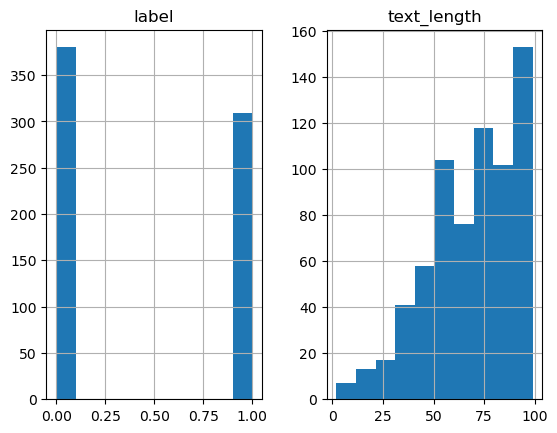

In [48]:
df[df['text_length']< 100].hist()

# Modeling